# Google Play Store Analysis

## Objective

This project performs an exploratory data analysis of the Google Play Store ecosystem.

The analysis focuses on:

- Data cleaning and preprocessing
- App category distribution
- App ratings
- App size and installation trends
- Free vs paid applications
- Price and estimated revenue analysis
- User review sentiment analysis
- Sentiment comparison across categories
- Interactive data visualization

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- VADER Sentiment Analysis
- Plotly
- Jupyter Notebook

# Importing Libraries

In [77]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# Loading the Two datasets

In [78]:
apps = pd.read_csv("play_store_apps.csv")

reviews = pd.read_csv("play_store_reviews.csv")

print("Apps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

Apps dataset shape: (89, 8)
Reviews dataset shape: (95, 3)


# Displaying First Few Rows

In [79]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price
0,WhatsApp Messenger,COMMUNICATION,4.3,158945000,58M,"1,000,000,000+",Free,0.0
1,Instagram,SOCIAL,4.5,665774000,38M,"1,000,000,000+",Free,0.0
2,Facebook,SOCIAL,4.1,781583000,Varies with device,"1,000,000,000+",Free,0.0
3,YouTube,VIDEO_PLAYERS,4.3,256235000,Varies with device,"1,000,000,000+",Free,0.0
4,Google Maps,TRAVEL_AND_LOCAL,4.3,92316100,35M,"1,000,000,000+",Free,0.0


In [80]:
reviews.head()

,App,Translated_Review,Sentiment
0,WhatsApp Messenger,"Amazing app, messaging is fast and reliable. I...",Positive
1,WhatsApp Messenger,The latest update is excellent and calls are m...,Positive
2,WhatsApp Messenger,The app keeps crashing after the update.,Negative
3,WhatsApp Messenger,Please improve the backup process.,Negative
4,Instagram,Love the new features and the interface looks ...,Positive


# Understanding the Dataset

In [81]:
print("Apps Dataset Information:")
apps.info()

Apps Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   App       89 non-null     str    
 1   Category  89 non-null     str    
 2   Rating    89 non-null     float64
 3   Reviews   89 non-null     int64  
 4   Size      89 non-null     str    
 5   Installs  89 non-null     str    
 6   Type      89 non-null     str    
 7   Price     89 non-null     float64
dtypes: float64(2), int64(1), str(5)
memory usage: 5.7 KB


In [82]:
print("Reviews Dataset Information:")
reviews.info()

Reviews Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   App                95 non-null     str  
 1   Translated_Review  95 non-null     str  
 2   Sentiment          95 non-null     str  
dtypes: str(3)
memory usage: 2.4 KB


# Checking Column Names

In [83]:
print("Apps columns:")
print(apps.columns.tolist())

print("\nReviews columns:")
print(reviews.columns.tolist())

Apps columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price']

Reviews columns:
['App', 'Translated_Review', 'Sentiment']


# Checking Missing Values

In [84]:
print("Missing values in Apps dataset:")
print(apps.isnull().sum())

Missing values in Apps dataset:
App         0
Category    0
Rating      0
Reviews     0
Size        0
Installs    0
Type        0
Price       0
dtype: int64


In [85]:
print("Missing values in Reviews dataset:")
print(reviews.isnull().sum())

Missing values in Reviews dataset:
App                  0
Translated_Review    0
Sentiment            0
dtype: int64


# Checking Duplicate Rows

In [86]:
print("Duplicate rows in Apps dataset:", apps.duplicated().sum())
print("Duplicate rows in Reviews dataset:", reviews.duplicated().sum())

Duplicate rows in Apps dataset: 0
Duplicate rows in Reviews dataset: 0


# Cleaning the Rating Column

In [87]:
apps["Rating"] = pd.to_numeric(apps["Rating"], errors="coerce")

print(apps["Rating"].dtype)

float64


# Handling Missing Ratings

In [88]:
apps_rating = apps.dropna(subset=["Rating"]).copy()

print("Rows available for rating analysis:", len(apps_rating))

Rows available for rating analysis: 89


# Cleaning Reviews Column

In [89]:
reviews["Translated_Review"] = reviews["Translated_Review"].fillna("")

reviews = reviews[reviews["Translated_Review"].str.strip() != ""]

print("Reviews available for sentiment analysis:", len(reviews))

Reviews available for sentiment analysis: 95


# Cleaning Installs

In [90]:
apps["Installs"] = (
    apps["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps["Installs"] = pd.to_numeric(apps["Installs"], errors="coerce")

apps["Installs"].head()

0    1000000000
1    1000000000
2    1000000000
3    1000000000
4    1000000000
Name: Installs, dtype: int64

# Cleaning Price

In [91]:
apps["Price"] = (
    apps["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps["Price"] = pd.to_numeric(apps["Price"], errors="coerce")


apps["Price"].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

# Cleaning Reviews

In [92]:
apps["Reviews"] = pd.to_numeric(
    apps["Reviews"],
    errors="coerce"
)

apps["Reviews"].head()

0    158945000
1    665774000
2    781583000
3    256235000
4     92316100
Name: Reviews, dtype: int64

# Cleaning App Size

In [93]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    
    size = str(size)
    
    if size == "Varies with device":
        return np.nan
    
    if size.endswith("M"):
        return float(size.replace("M", ""))
    
    elif size.endswith("k"):
        return float(size.replace("k", "")) / 1024
    
    return np.nan


apps["Size_MB"] = apps["Size"].apply(convert_size)

apps[["Size", "Size_MB"]].head(10)

,Size,Size_MB
0,58M,58.0
1,38M,38.0
2,Varies with device,NaN
3,Varies with device,NaN
4,35M,35.0
5,Varies with device,NaN
6,Varies with device,NaN
7,Varies with device,NaN
8,Varies with device,NaN
9,Varies with device,NaN


# Checking Cleaned Dataset

In [94]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   App       89 non-null     str    
 1   Category  89 non-null     str    
 2   Rating    89 non-null     float64
 3   Reviews   89 non-null     int64  
 4   Size      89 non-null     str    
 5   Installs  89 non-null     int64  
 6   Type      89 non-null     str    
 7   Price     89 non-null     float64
 8   Size_MB   45 non-null     float64
dtypes: float64(3), int64(2), str(4)
memory usage: 6.4 KB


# Summary Statistics

In [95]:
apps.describe()

,Rating,Reviews,Installs,Price,Size_MB
count,89.000000,8.900000e+01,8.900000e+01,89.000000,45.000000
mean,4.407865,2.671411e+07,1.849309e+08,0.431236,24.237778
std,0.210100,1.119474e+08,3.299899e+08,1.412334,41.905778
min,4.000000,3.878900e+04,5.000000e+04,0.000000,5.200000
25%,4.300000,6.636700e+04,5.000000e+05,0.000000,12.000000
50%,4.400000,2.400000e+05,1.000000e+07,0.000000,16.000000
75%,4.600000,5.200000e+06,1.000000e+08,0.000000,20.000000
max,4.800000,7.815830e+08,1.000000e+09,6.990000,280.000000


In [96]:
apps_rating["Rating"].describe()

count    89.000000
mean      4.407865
std       0.210100
min       4.000000
25%       4.300000
50%       4.400000
75%       4.600000
max       4.800000
Name: Rating, dtype: float64

# Category Analysis

In [97]:
category_counts = apps["Category"].value_counts()

category_counts

Category
PRODUCTIVITY           10
GAME                    9
PHOTOGRAPHY             7
FAMILY                  6
TOOLS                   6
SOCIAL                  5
TRAVEL_AND_LOCAL        5
HEALTH_AND_FITNESS      4
FOOD_AND_DRINK          4
SHOPPING                4
SPORTS                  4
COMMUNICATION           3
MUSIC_AND_AUDIO         3
VIDEO_PLAYERS           2
ART_AND_DESIGN          2
WEATHER                 2
BOOKS_AND_REFERENCE     2
FINANCE                 2
EDUCATION               2
BUSINESS                2
NEWS_AND_MAGAZINES      2
HOUSE_AND_HOME          2
PERSONALIZATION         1
Name: count, dtype: int64

# Category Bar Chart

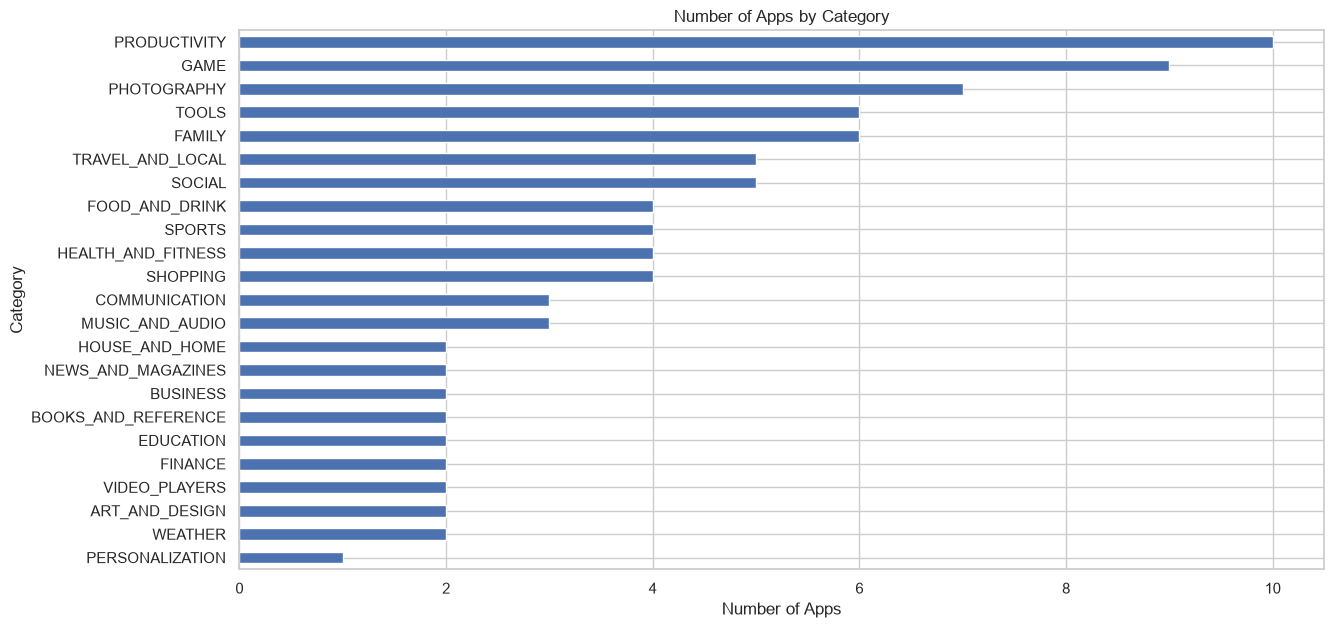

In [98]:
plt.figure(figsize=(14, 7))

category_counts.sort_values().plot(
    kind="barh"
)

plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.show()

# Top 10 Categories

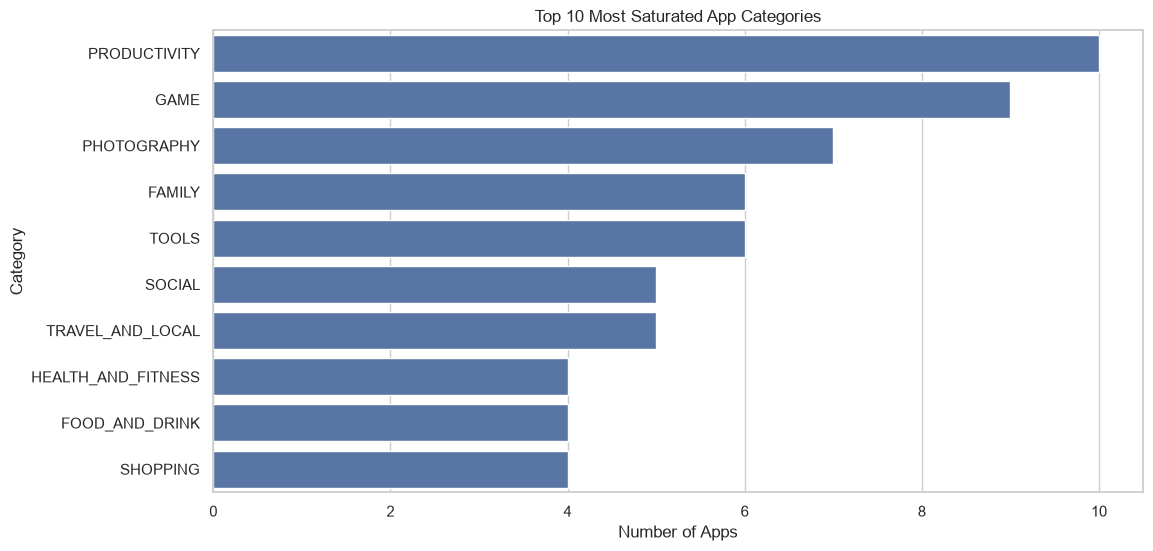

In [99]:
top_categories = category_counts.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Most Saturated App Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.show()

# Ratings Distribution

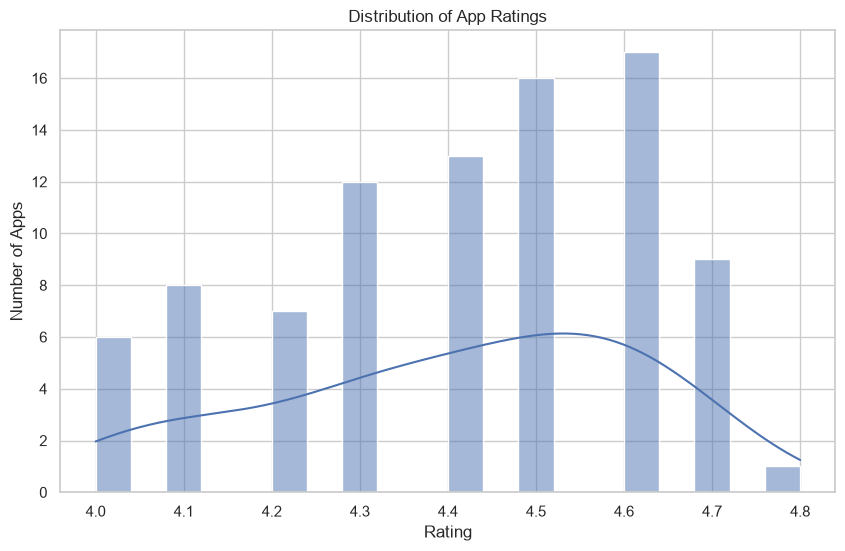

In [100]:
plt.figure(figsize=(10, 6))

sns.histplot(
    apps_rating["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

# Average Rating

In [101]:
average_rating = apps_rating["Rating"].mean()

print(f"Average Play Store app rating: {average_rating:.2f}")

Average Play Store app rating: 4.41


# Average Rating by Category

In [102]:
category_rating = (
    apps_rating
    .groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

category_rating

Category
PERSONALIZATION        4.700000
ART_AND_DESIGN         4.600000
GAME                   4.555556
BOOKS_AND_REFERENCE    4.550000
HOUSE_AND_HOME         4.550000
PRODUCTIVITY           4.480000
MUSIC_AND_AUDIO        4.466667
EDUCATION              4.450000
FINANCE                4.450000
COMMUNICATION          4.433333
FAMILY                 4.433333
TOOLS                  4.433333
PHOTOGRAPHY            4.414286
HEALTH_AND_FITNESS     4.400000
VIDEO_PLAYERS          4.350000
SPORTS                 4.350000
FOOD_AND_DRINK         4.350000
SOCIAL                 4.340000
BUSINESS               4.300000
WEATHER                4.300000
TRAVEL_AND_LOCAL       4.180000
NEWS_AND_MAGAZINES     4.150000
SHOPPING               4.150000
Name: Rating, dtype: float64

# Plot Average Rating by Category

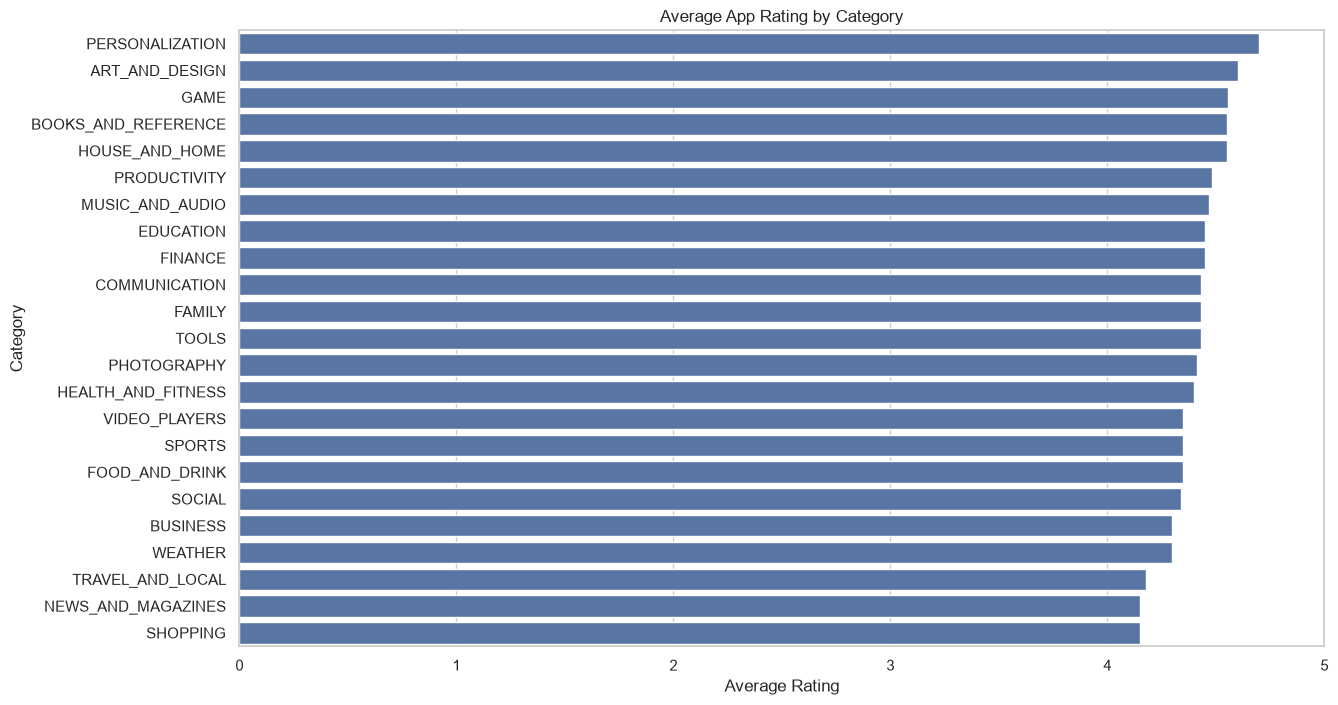

In [103]:
plt.figure(figsize=(14, 8))

sns.barplot(
    x=category_rating.values,
    y=category_rating.index
)

plt.title("Average App Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.xlim(0, 5)

plt.show()

# Size vs Installs

In [104]:
size_install_df = apps.dropna(
    subset=["Size_MB", "Installs"]
).copy()

size_install_df = size_install_df[
    size_install_df["Installs"] > 0
]

size_install_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Size_MB
0,WhatsApp Messenger,COMMUNICATION,4.3,158945000,58M,1000000000,Free,0.0,58.0
1,Instagram,SOCIAL,4.5,665774000,38M,1000000000,Free,0.0,38.0
4,Google Maps,TRAVEL_AND_LOCAL,4.3,92316100,35M,1000000000,Free,0.0,35.0
15,Candy Crush Saga,GAME,4.4,22400000,74M,1000000000,Free,0.0,74.0
16,Subway Surfers,GAME,4.5,35000000,76M,1000000000,Free,0.0,76.0


# Scatter Plot

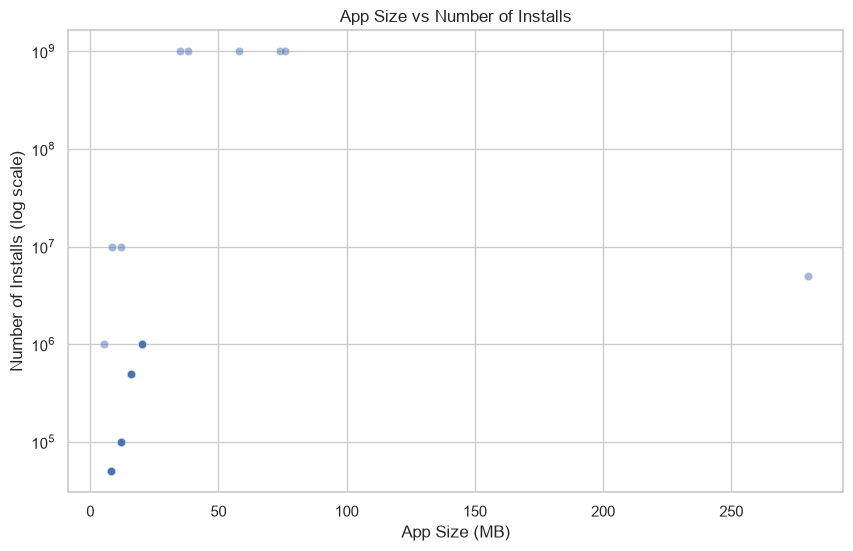

In [105]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_install_df,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.yscale("log")

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs (log scale)")

plt.show()

# Correlation

In [106]:
correlation = size_install_df[
    ["Size_MB", "Installs"]
].corr()

correlation

,Size_MB,Installs
Size_MB,1.000000,0.274495
Installs,0.274495,1.000000


In [108]:
correlation_value = size_install_df[
    "Size_MB"
].corr(
    size_install_df["Installs"]
)

print(f"Correlation between app size and installs: {correlation_value:.3f}")

Correlation between app size and installs: 0.274


### The correlation coefficient indicates the strength and direction of the linear relationship between app size and installs. A value close to zero would indicate little linear relationship.

# Free vs Paid Apps

In [109]:
type_counts = apps["Type"].value_counts()

type_counts

Type
Free    81
Paid     8
Name: count, dtype: int64

# Free vs Paid Apps Chart

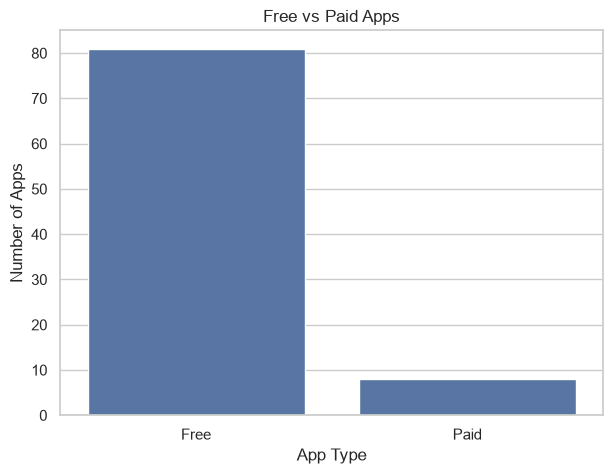

In [110]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.show()

# Percentage of Free vs Paid Apps

In [111]:
type_percentage = (
    apps["Type"]
    .value_counts(normalize=True)
    .mul(100)
)

print(type_percentage.round(2))

Type
Free    91.01
Paid     8.99
Name: proportion, dtype: float64


# Paid Apps Price Distribution

In [12]:
paid_apps = apps[
    (apps["Type"] == "Paid") &
    (apps["Price"] > 0)
].copy()

print("Number of paid apps:", len(paid_apps))

Number of paid apps: 8


# Price Distribution

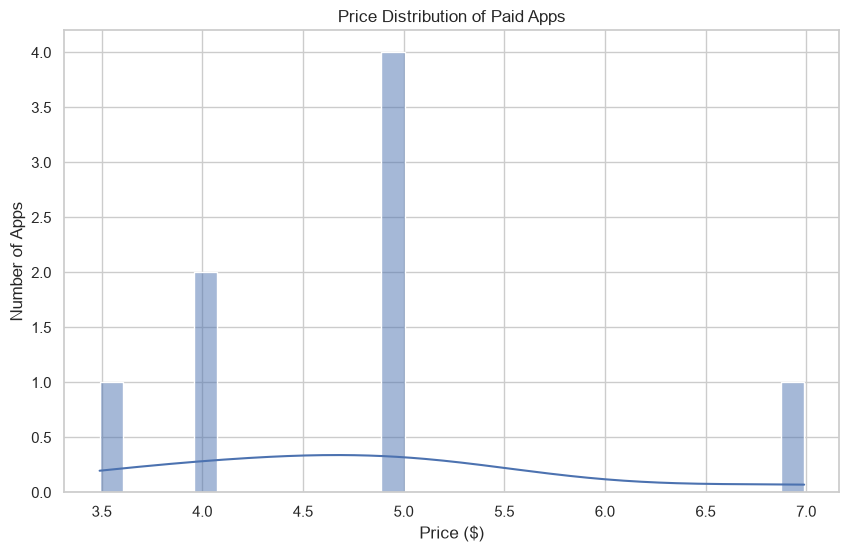

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.show()

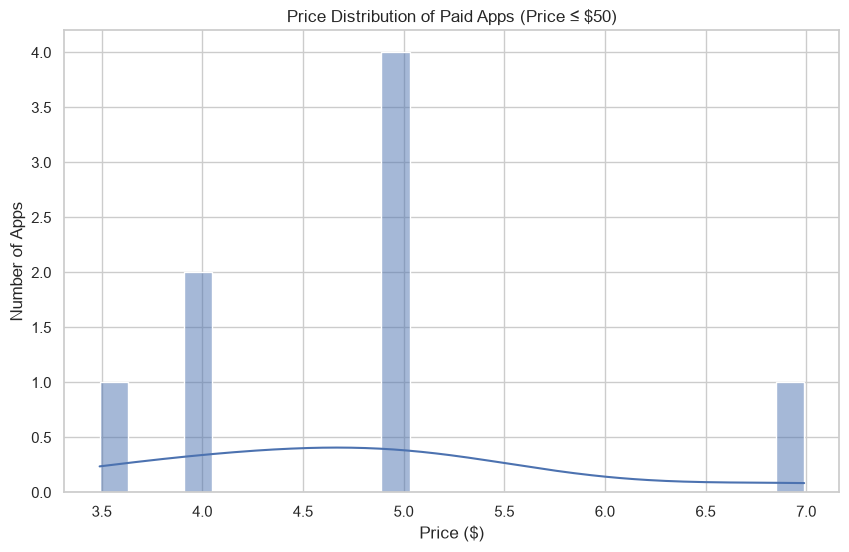

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps[paid_apps["Price"] <= 50]["Price"],
    bins=25,
    kde=True
)

plt.title("Price Distribution of Paid Apps (Price ≤ $50)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.show()

# Average Paid App Price

In [10]:
print(
    f"Average paid app price: ${paid_apps['Price'].mean():.2f}"
)

print(
    f"Median paid app price: ${paid_apps['Price'].median():.2f}"
)

Average paid app price: $4.80
Median paid app price: $4.97


# Revenue Estimation

In [22]:
# Convert Installs to numeric
paid_apps["Installs"] = (
    paid_apps["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Make sure Price is numeric
paid_apps["Price"] = pd.to_numeric(
    paid_apps["Price"],
    errors="coerce"
)

# Calculate estimated revenue
paid_apps["Estimated_Revenue"] = (
    paid_apps["Installs"] * paid_apps["Price"]
)

paid_apps[
    ["App", "Category", "Installs", "Price", "Estimated_Revenue"]
].head()

,App,Category,Installs,Price,Estimated_Revenue
18,Minecraft,GAME,50000000.0,6.99,349500000.0
19,Monument Valley,GAME,5000000.0,3.99,19950000.0
29,Pocket Casts,MUSIC_AND_AUDIO,1000000.0,3.99,3990000.0
30,Poweramp Full Version Unlocker,MUSIC_AND_AUDIO,1000000.0,4.99,4990000.0
31,Nova Launcher Prime,PERSONALIZATION,10000000.0,4.99,49900000.0


# Revenue by Category

In [63]:
revenue_by_category = (
    paid_apps
    .groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category

Category
GAME                   369450000.0
PERSONALIZATION         49900000.0
TOOLS                   39850000.0
MUSIC_AND_AUDIO          8980000.0
BOOKS_AND_REFERENCE      4990000.0
Name: Estimated_Revenue, dtype: float64

# Revenue Chart

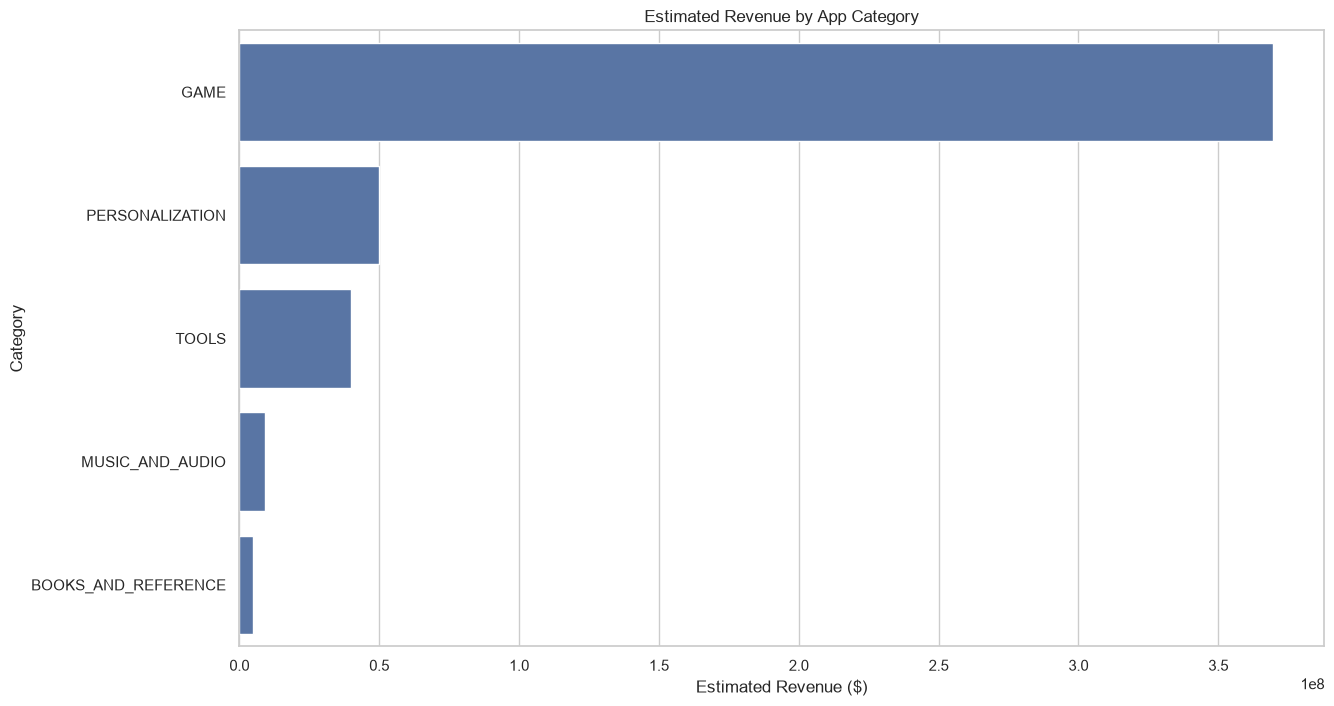

In [62]:
plt.figure(figsize=(14, 8))

sns.barplot(
    x=revenue_by_category.values,
    y=revenue_by_category.index
)

plt.title("Estimated Revenue by App Category")
plt.xlabel("Estimated Revenue ($)")
plt.ylabel("Category")

plt.show()

# Top Revenue Categories

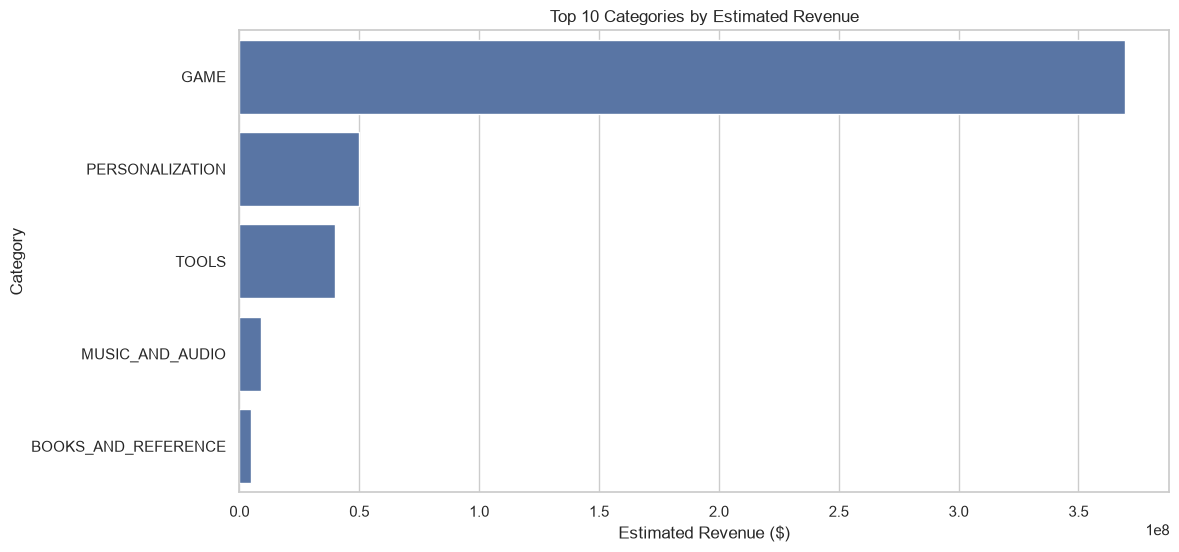

In [25]:
top_revenue_categories = revenue_by_category.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_revenue_categories.values,
    y=top_revenue_categories.index
)

plt.title("Top 10 Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue ($)")
plt.ylabel("Category")

plt.show()

# Sentiment Analysis

In [26]:
analyzer = SentimentIntensityAnalyzer()

In [27]:
reviews[
    ["App", "Translated_Review"]
].head(10)

,App,Translated_Review
0,WhatsApp Messenger,"Amazing app, messaging is fast and reliable. I..."
1,WhatsApp Messenger,The latest update is excellent and calls are m...
2,WhatsApp Messenger,The app keeps crashing after the update.
3,WhatsApp Messenger,Please improve the backup process.
4,Instagram,Love the new features and the interface looks ...
5,Instagram,Photos load quickly and stories work perfectly.
6,Instagram,Too many ads and the app feels slow now.
7,Instagram,The app is okay but could use better controls.
8,Facebook,Very useful for keeping in touch with friends.
9,Facebook,The feed is full of irrelevant posts.


In [28]:
def get_sentiment_score(text):
    return analyzer.polarity_scores(text)["compound"]


reviews["compound_score"] = reviews[
    "Translated_Review"
].apply(get_sentiment_score)

# Classify Reviews

In [29]:
def classify_sentiment(score):
    if score >= 0.5:
        return "Positive"
    elif score <= -0.5:
        return "Negative"
    else:
        return "Neutral"


reviews["Sentiment_VADER"] = reviews[
    "compound_score"
].apply(classify_sentiment)

# Check Sentiment Analysis

In [30]:
reviews[
    [
        "App",
        "Translated_Review",
        "compound_score",
        "Sentiment_VADER"
    ]
].head(20)

,App,Translated_Review,compound_score,Sentiment_VADER
0,WhatsApp Messenger,"Amazing app, messaging is fast and reliable. I...",0.5859,Positive
1,WhatsApp Messenger,The latest update is excellent and calls are m...,0.5719,Positive
2,WhatsApp Messenger,The app keeps crashing after the update.,0.0000,Neutral
3,WhatsApp Messenger,Please improve the backup process.,0.6369,Positive
4,Instagram,Love the new features and the interface looks ...,0.8519,Positive
5,Instagram,Photos load quickly and stories work perfectly.,0.6369,Positive
6,Instagram,Too many ads and the app feels slow now.,0.0000,Neutral
7,Instagram,The app is okay but could use better controls.,0.6486,Positive
8,Facebook,Very useful for keeping in touch with friends.,0.7425,Positive
9,Facebook,The feed is full of irrelevant posts.,0.0000,Neutral


# Sentiment Distribution

In [31]:
sentiment_counts = reviews[
    "Sentiment_VADER"
].value_counts()

sentiment_counts

Sentiment_VADER
Neutral     53
Positive    41
Negative     1
Name: count, dtype: int64

# Sentiment Bar Chart

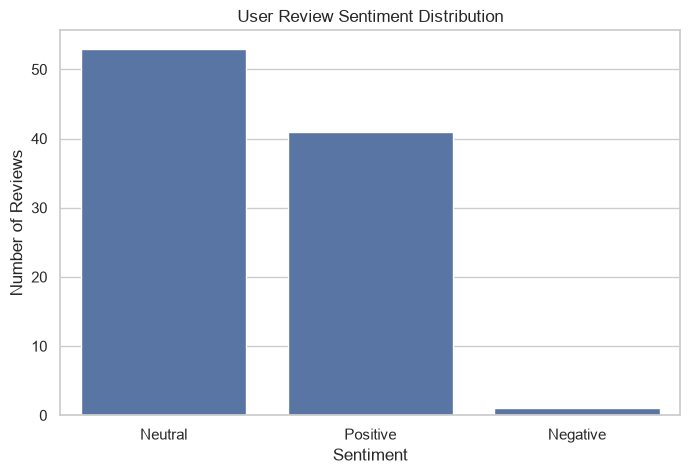

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

# Sentiment Percentage

In [33]:
sentiment_percentage = (
    reviews["Sentiment_VADER"]
    .value_counts(normalize=True)
    .mul(100)
)

print(sentiment_percentage.round(2))

Sentiment_VADER
Neutral     55.79
Positive    43.16
Negative     1.05
Name: proportion, dtype: float64


# Merge Reviews with App Categories

In [34]:
review_category = reviews.merge(
    apps[["App", "Category"]],
    on="App",
    how="left"
)

review_category.head()

,App,Translated_Review,Sentiment,compound_score,Sentiment_VADER,Category
0,WhatsApp Messenger,"Amazing app, messaging is fast and reliable. I...",Positive,0.5859,Positive,COMMUNICATION
1,WhatsApp Messenger,The latest update is excellent and calls are m...,Positive,0.5719,Positive,COMMUNICATION
2,WhatsApp Messenger,The app keeps crashing after the update.,Negative,0.0000,Neutral,COMMUNICATION
3,WhatsApp Messenger,Please improve the backup process.,Negative,0.6369,Positive,COMMUNICATION
4,Instagram,Love the new features and the interface looks ...,Positive,0.8519,Positive,SOCIAL


# Checking Missing Categories

In [35]:
print(
    "Reviews without category:",
    review_category["Category"].isna().sum()
)

Reviews without category: 0


# Sentiment by Category

In [36]:
category_sentiment = (
    review_category
    .groupby("Category")["compound_score"]
    .mean()
    .sort_values(ascending=False)
)

category_sentiment

Category
BOOKS_AND_REFERENCE    0.631350
HOUSE_AND_HOME         0.558800
MUSIC_AND_AUDIO        0.558740
FINANCE                0.532650
ART_AND_DESIGN         0.496750
VIDEO_PLAYERS          0.447720
SOCIAL                 0.409045
GAME                   0.402630
FAMILY                 0.394880
HEALTH_AND_FITNESS     0.374260
FOOD_AND_DRINK         0.320675
SHOPPING               0.318450
TOOLS                  0.305267
COMMUNICATION          0.288787
EDUCATION              0.257700
SPORTS                 0.253075
TRAVEL_AND_LOCAL       0.246800
PERSONALIZATION        0.226300
BUSINESS               0.220200
PHOTOGRAPHY            0.185325
PRODUCTIVITY           0.112225
NEWS_AND_MAGAZINES     0.095200
WEATHER               -0.190900
Name: compound_score, dtype: float64

# Positive Sentiment by Category

In [37]:
positive_by_category = (
    review_category[
        review_category["Sentiment_VADER"] == "Positive"
    ]
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

positive_by_category.head(10)

Category
GAME                   7
SOCIAL                 6
FAMILY                 4
ART_AND_DESIGN         3
COMMUNICATION          3
MUSIC_AND_AUDIO        3
HEALTH_AND_FITNESS     2
EDUCATION              2
BOOKS_AND_REFERENCE    2
VIDEO_PLAYERS          2
dtype: int64

# Negative Sentiment by Category

In [38]:
negative_by_category = (
    review_category[
        review_category["Sentiment_VADER"] == "Negative"
    ]
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

negative_by_category.head(10)

Category
TRAVEL_AND_LOCAL    1
dtype: int64

# Most Positive Categories

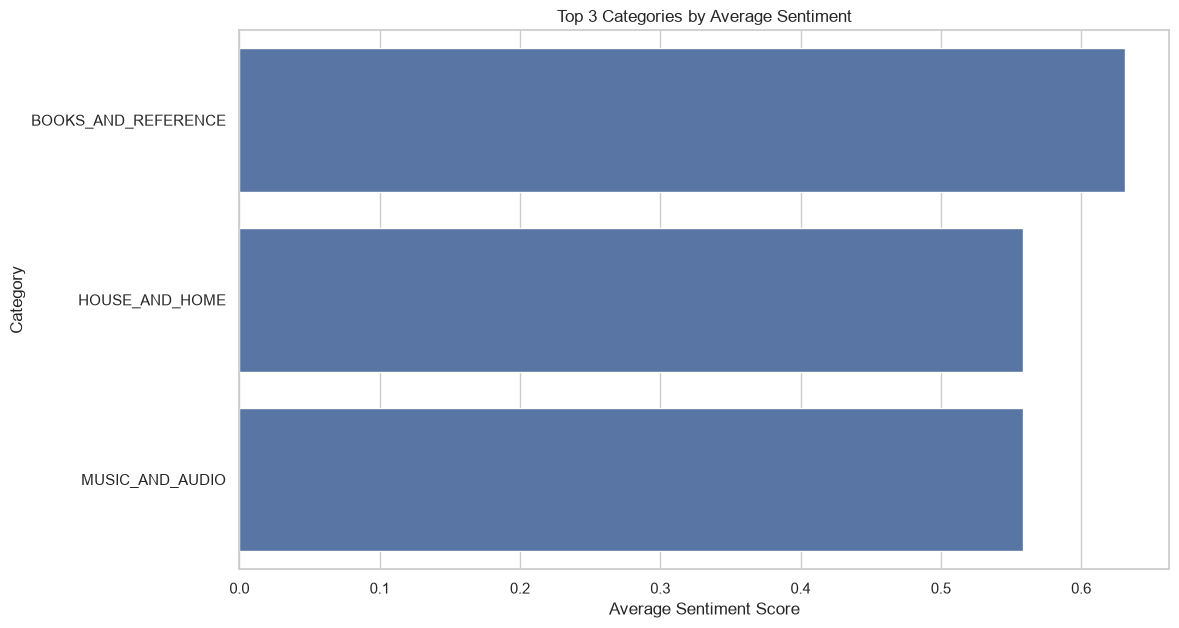

In [40]:
plt.figure(figsize=(12, 7))

top_positive = category_sentiment.head(3)

sns.barplot(
    x=top_positive.values,
    y=top_positive.index
)

plt.title("Top 3 Categories by Average Sentiment")
plt.xlabel("Average Sentiment Score")
plt.ylabel("Category")

plt.show()

# Most Negative Categories

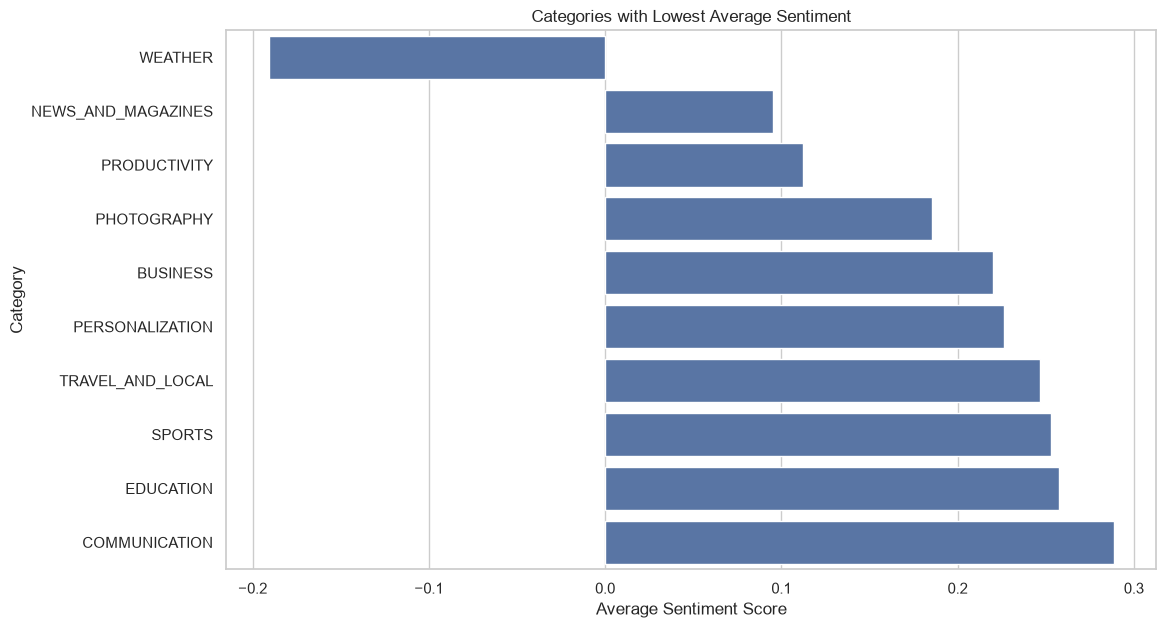

In [41]:
plt.figure(figsize=(12, 7))

top_negative = category_sentiment.tail(10).sort_values()

sns.barplot(
    x=top_negative.values,
    y=top_negative.index
)

plt.title("Categories with Lowest Average Sentiment")
plt.xlabel("Average Sentiment Score")
plt.ylabel("Category")

plt.show()

# Sentiment Counts by Categories

In [42]:
sentiment_category = pd.crosstab(
    review_category["Category"],
    review_category["Sentiment_VADER"]
)

sentiment_category.head()

Sentiment_VADER,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,0,1,3
BOOKS_AND_REFERENCE,0,0,2
BUSINESS,0,4,0
COMMUNICATION,0,5,3
EDUCATION,0,1,2


# Stacked Sentiment Chart

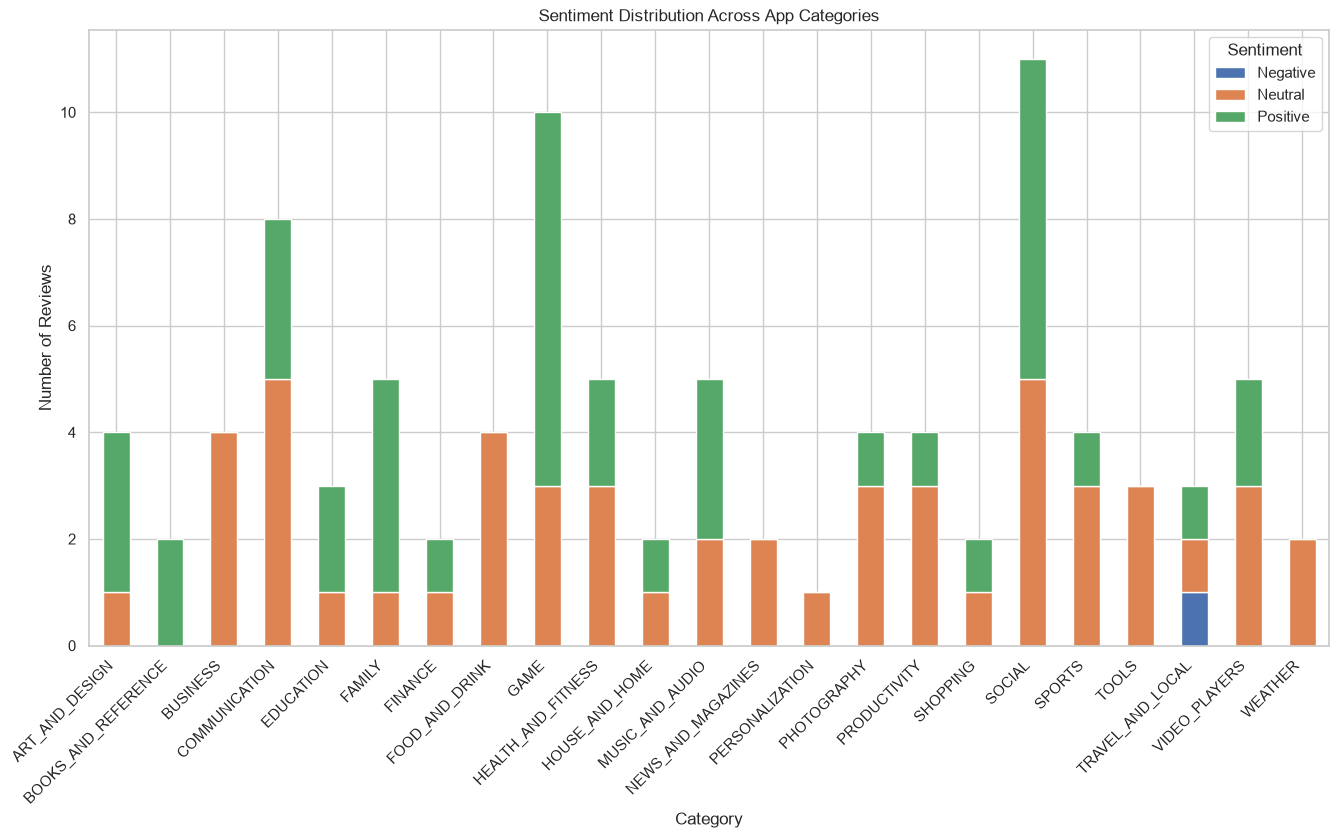

In [43]:
sentiment_category.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 8)
)

plt.title("Sentiment Distribution Across App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45, ha="right")

plt.legend(title="Sentiment")

plt.show()

# Interactive Plotly Visualization

In [44]:
plotly_category = (
    apps.groupby("Category")
    .agg(
        App_Count=("App", "count"),
        Average_Rating=("Rating", "mean"),
        Total_Installs=("Installs", "sum")
    )
    .reset_index()
)

plotly_category.head()

,Category,App_Count,Average_Rating,Total_Installs
0,ART_AND_DESIGN,2,4.600000,200000000
1,BOOKS_AND_REFERENCE,2,4.550000,11000000
2,BUSINESS,2,4.300000,1100000000
3,COMMUNICATION,3,4.433333,1510000000
4,EDUCATION,2,4.450000,20000000


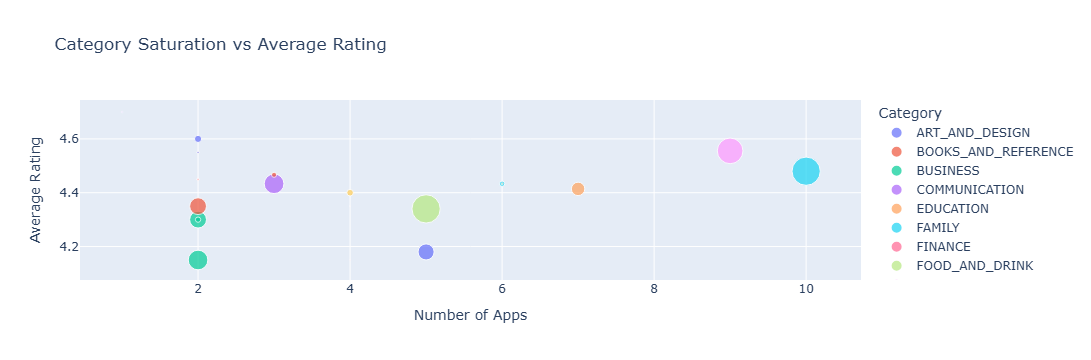

In [45]:
fig = px.scatter(
    plotly_category,
    x="App_Count",
    y="Average_Rating",
    size="Total_Installs",
    color="Category",
    hover_name="Category",
    title="Category Saturation vs Average Rating",
    labels={
        "App_Count": "Number of Apps",
        "Average_Rating": "Average Rating"
    }
)

fig.show()

# Correlation Heatmap

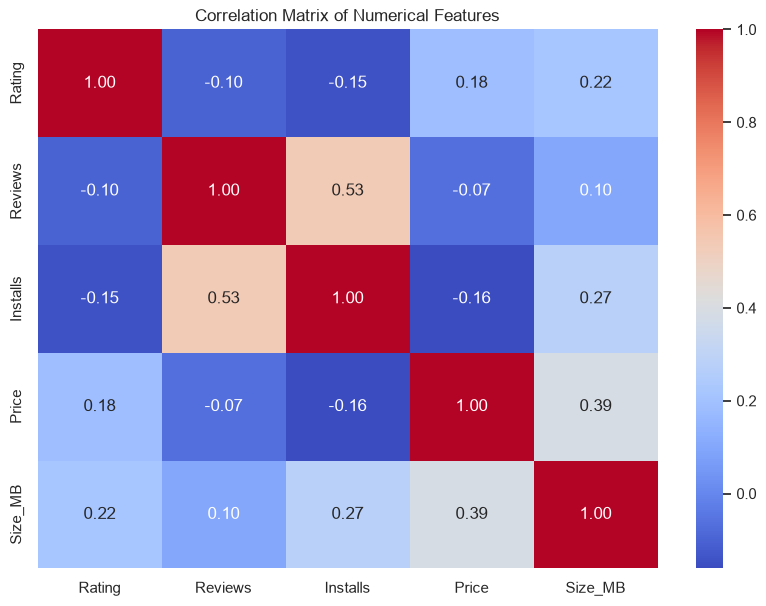

In [50]:
numeric_columns = [
    "Rating",
    "Reviews",
    "Installs",
    "Price",
    "Size_MB"
]

correlation_matrix = apps[
    numeric_columns
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

# Most Installed Apps

In [51]:
top_installed = (
    apps
    .sort_values("Installs", ascending=False)
    [["App", "Category", "Installs", "Rating"]]
    .head(10)
)

top_installed

,App,Category,Installs,Rating
0,WhatsApp Messenger,COMMUNICATION,1000000000,4.3
1,Instagram,SOCIAL,1000000000,4.5
2,Facebook,SOCIAL,1000000000,4.1
3,YouTube,VIDEO_PLAYERS,1000000000,4.3
4,Google Maps,TRAVEL_AND_LOCAL,1000000000,4.3
7,Google Drive,PRODUCTIVITY,1000000000,4.4
15,Candy Crush Saga,GAME,1000000000,4.4
16,Subway Surfers,GAME,1000000000,4.5
44,Google News,NEWS_AND_MAGAZINES,1000000000,4.2
42,LinkedIn,BUSINESS,1000000000,4.2


# Highest Rated Apps

In [122]:
high_rated_apps = apps[
    apps["Reviews"] >= 1000
].sort_values(
    "Rating",
    ascending=False
)

high_rated_apps[
    ["App", "Category", "Rating", "Reviews"]
].head(10)

,App,Category,Rating,Reviews
19,Monument Valley,GAME,4.8,240000
10,Duolingo,FAMILY,4.7,11200000
23,Canva,ART_AND_DESIGN,4.7,5200000
68,Google Calendar,PRODUCTIVITY,4.7,80156
78,Swiggy,FOOD_AND_DRINK,4.7,52578
86,FIFA,SPORTS,4.7,52578
63,File Manager,TOOLS,4.7,66367
54,Kids Learning,FAMILY,4.7,52578
31,Nova Launcher Prime,PERSONALIZATION,4.7,350000
60,Angry Birds,GAME,4.7,80156


# Final Summary Table

In [123]:
summary = pd.DataFrame({
    "Metric": [
        "Total Apps",
        "Total Reviews",
        "Average Rating",
        "Free Apps",
        "Paid Apps",
        "Most Saturated Category",
        "Highest Average Rating Category",
        "Highest Estimated Revenue Category"
    ],
    
    "Value": [
        len(apps),
        len(reviews),
        round(apps_rating["Rating"].mean(), 2),
        (apps["Type"] == "Free").sum(),
        (apps["Type"] == "Paid").sum(),
        category_counts.idxmax(),
        category_rating.idxmax(),
        revenue_by_category.idxmax()
    ]
})

summary

,Metric,Value
0,Total Apps,89
1,Total Reviews,95
2,Average Rating,4.41
3,Free Apps,81
4,Paid Apps,8
5,Most Saturated Category,PRODUCTIVITY
6,Highest Average Rating Category,PERSONALIZATION
7,Highest Estimated Revenue Category,GAME


# Automatically Generate Insights

In [124]:
print("KEY INSIGHTS")
print("=" * 50)

print(
    f"1. The most saturated category is "
    f"{category_counts.idxmax()} "
    f"with {category_counts.max():,} apps."
)

print(
    f"2. The highest average-rated category is "
    f"{category_rating.idxmax()} "
    f"with an average rating of "
    f"{category_rating.max():.2f}."
)

print(
    f"3. The category with the highest estimated "
    f"revenue among paid apps is "
    f"{revenue_by_category.idxmax()}."
)

print(
    f"4. The correlation between app size and installs "
    f"is {correlation_value:.3f}."
)

print(
    f"5. The most common review sentiment is "
    f"{sentiment_counts.idxmax()}."
)

KEY INSIGHTS
1. The most saturated category is PRODUCTIVITY with 10 apps.
2. The highest average-rated category is PERSONALIZATION with an average rating of 4.70.
3. The category with the highest estimated revenue among paid apps is GAME.
4. The correlation between app size and installs is 0.274.
5. The most common review sentiment is Neutral.


# Conclusion

## Key Findings

### 1. Market Saturation

The category analysis shows that some categories contain substantially more applications than others. These highly populated categories represent competitive markets where developers may need stronger differentiation, better user experience, or a more focused niche.

### 2. Ratings and User Experience

The ratings analysis shows that average ratings vary across categories. Developers should therefore study the expectations and pain points of users within their target category before launching a new application.

### 3. Monetization

The Play Store contains a very large proportion of free applications compared with paid applications. This suggests that developers should carefully evaluate their monetization strategy, including advertising, subscriptions, in-app purchases, or premium features.

### 4. App Size and Installs

The correlation analysis between application size and installs helps determine whether app size has a meaningful linear relationship with adoption. However, correlation should not be interpreted as causation.

### 5. User Sentiment

VADER sentiment analysis provides an overview of positive, neutral, and negative user feedback. Categories with higher negative sentiment may provide opportunities for developers to solve existing user problems and improve the user experience.

## Recommendations for a New Developer

1. Avoid entering highly saturated categories without a clear unique selling proposition.
2. Prioritize user experience and actively monitor negative reviews.
3. Choose a monetization strategy based on the target audience and category rather than assuming users will pay for the application.

# Exporting Final Summary 

In [125]:
summary.to_csv(
    "google_play_store_analysis_summary.csv",
    index=False
)

print("Summary exported successfully.")

Summary exported successfully.
